In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
lines_list = []
lines_list_im = []
# fre contains not centered with size
# fre2 is centered point source
# fre3: fcen = 0.25, df = 1.5, gaussian point source at (0.1234,0)
# fre4: fcen = 0.25, df = 0.75, gaussian point source at (0.1234,0), (res:30), Y sym phase=-1
# fre5: fcen = 0.25, df = 1.5, gaussian point source at (0,0.1234)
# fre6: fcen = 0.25, df = 0.75, gaussian point source at (0.1234,0), (res:30), no sym
# fre7: fcen = 0.25, df = 0.75, gaussian point source at (0.1234,0), (res:30), Y sym phase=1
# fre9: fcen = 0.225, df = 0.775, odd, (res:30)
# fre10: fcen = 0.225, df = 0.775, even, (res:30)

# 3D
# fre11: fcen = 0.225, df = 1.525, "odd", (res:20), (no pml oops)
# fre12: fcen = 0.225, df = 1.525, "odd", (res:20), pml layers
# fre13: fcen = 0.225, df = 1.525, "even", (res:20), pml layers
# fre14: fcen = 0.225, df = 1.525, "even", (res:20), pml layers of 2.9 thickness
with open("dot_dat_files/fre13.dat","r") as f:
    lines = f.readlines()
    for line in lines:
        line_list = list(map(float,line.split(", ")))
        lines_list.append(line_list)
with open("dot_dat_files/fim13.dat","r") as f:
    lines = f.readlines()
    for line in lines:
        line_list = list(map(float,line.split(", ")))
        lines_list_im.append(line_list)

In [4]:
k_points = [float(line[1]) for line in lines_list]

In [5]:
max_len = max(len(line) for line in lines_list)
for line in lines_list:
    if len(line) < max_len:
        line.extend([np.nan] * (max_len - len(line)))
for line in lines_list_im:
    if len(line) < max_len:
        line.extend([np.nan] * (max_len - len(line)))

In [6]:
# The columns of the following matrix represent the detected frequencies for each k value
omegas_re = np.array(lines_list).T[4:]
omegas_im = np.array(lines_list_im).T[4:]

Q = omegas_re/(-2*omegas_im)

In [7]:
celerity = 299792458
h_bar = 1.054571817e-34
a = 426e-9
e =  1.60217646e-19
energies = h_bar*omegas_re*2*np.pi*celerity/(a*e) # energies in eV instead of omega*a/2pi*c

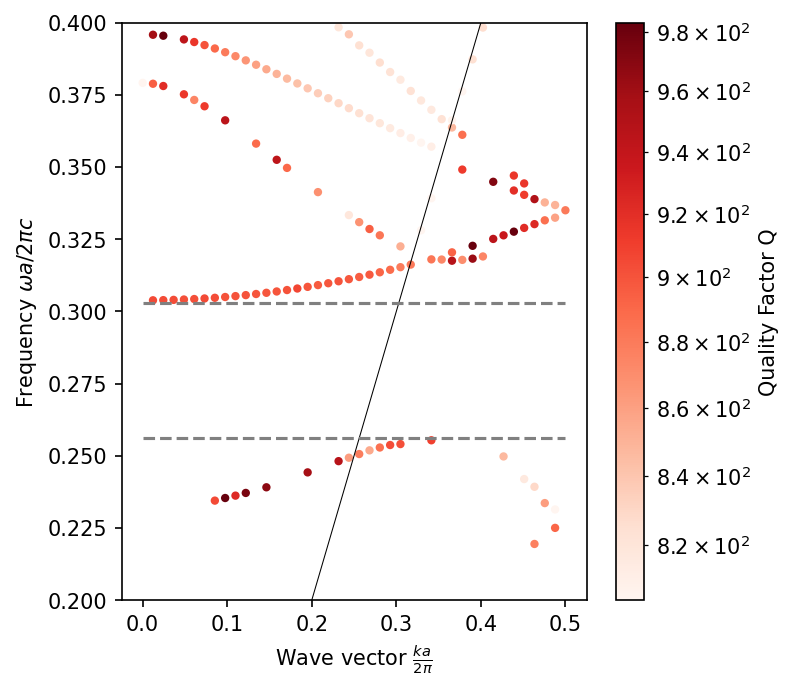

In [15]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(5,5), dpi=150)
for n in range(len(omegas_re)):
    sc = plt.scatter(k_points, omegas_re[n], c=Q[n], cmap='Reds', norm=LogNorm(), marker='.')

plt.plot(k_points, k_points, 'k', lw=0.5)
plt.plot([0,0.5], [0,0.5/np.sqrt(11.68)])
plt.hlines(y=[0.256,0.303], xmin=0, xmax=0.5, colors='grey', ls='--')
plt.ylabel(r'Frequency $\omega a/2\pi c$')
plt.xlabel(r'Wave vector $\frac{ka}{2\pi}$')
plt.ylim((0.2,0.4))
plt.colorbar(sc, label='Quality Factor Q')
plt.show()

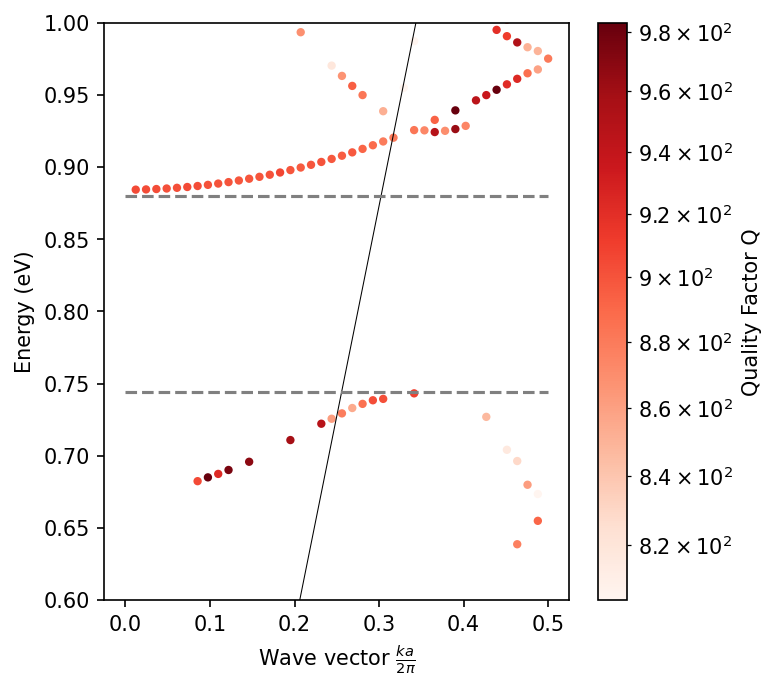

In [9]:
plt.figure(figsize=(5,5), dpi=150)
for n in range(len(energies)):
    sc = plt.scatter(k_points, energies[n], c=Q[n], cmap='Reds', norm=LogNorm(), marker='.')
    
plt.plot([0,0.5], [0,h_bar*0.5*2*np.pi*celerity/a/e], 'k', lw=0.5)
plt.plot([0,0.5], [0,h_bar*0.5/np.sqrt(11.68)*2*np.pi*celerity/a/e])
plt.hlines(y=[0.744,0.88], xmin=0, xmax=0.5, colors='grey', ls='--')
plt.ylabel(r'Energy (eV)')
plt.xlabel(r'Wave vector $\frac{ka}{2\pi}$')
plt.colorbar(sc, label='Quality Factor Q')
plt.ylim(0.6,1)
plt.show()